**Jamboree** has helped thousands of students like you make it to top colleges abroad. Be it GMAT, GRE or SAT, their unique problem-solving methods ensure maximum scores with minimum effort.They recently launched a feature where students/learners can come to their website and check their probability of getting into the IVY league college. This feature estimates the chances of graduate admission from an Indian perspective.

**Problem Statement :** Your analysis will help Jamboree in understanding what factors are important in graduate admissions and how these factors are interrelated among themselves. It will also help predict one's chances of admission given the rest of the variables.

In [1]:
import pandas as pd

df = pd.read_csv("Jamboree_Admission.csv")
df.head(5)

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [3]:
df.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


In [4]:
df.shape

(500, 9)

#### Check for Unique Values

In [5]:
print('\nNumber of unique attributes for each column:')
display(df.nunique())


Number of unique attributes for each column:


Serial No.           500
GRE Score             49
TOEFL Score           29
University Rating      5
SOP                    9
LOR                    9
CGPA                 184
Research               2
Chance of Admit       61
dtype: int64

In [6]:
# Get data types of all columns
display(df.dtypes)

Serial No.             int64
GRE Score              int64
TOEFL Score            int64
University Rating      int64
SOP                  float64
LOR                  float64
CGPA                 float64
Research               int64
Chance of Admit      float64
dtype: object

In [7]:
# check for missing values

df.isnull().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

**Performing Exploratory Data Analysis**





In [8]:
df.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')

In [9]:
# Renaming "LOR" and 'Chance of Admit' as there are trailing spaces are present which can cause issue.

df.rename(columns={'LOR ': 'LOR', 'Chance of Admit ': 'Chance of Admit'}, inplace=True)
df.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR', 'CGPA', 'Research', 'Chance of Admit'],
      dtype='object')

We noticed that 'University Rating', 'SOP','LOR', and 'Research' are showing categorical nature as we going to consider them as categorical columns and also creating a separte varible for numerical columns.

In [10]:
cat_cols = ['University Rating', 'SOP','LOR', 'Research']
num_cols = ['GRE Score', 'TOEFL Score', 'CGPA','Chance of Admit']

#### **Univariate Anlysis for Numerical columns**

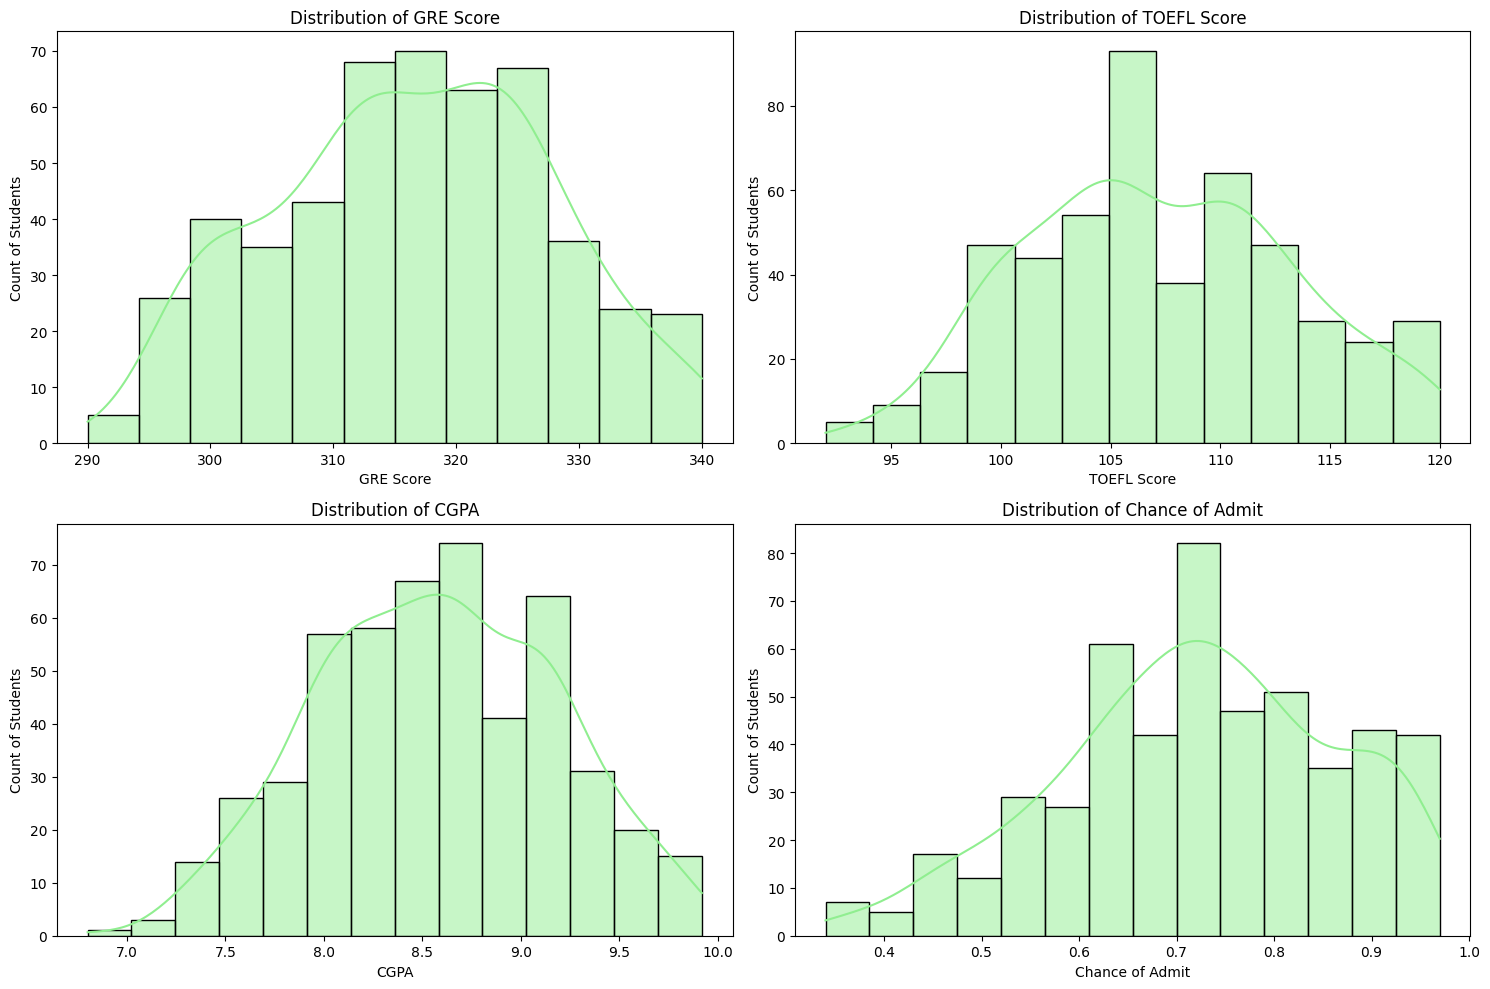

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols):
  plt.subplot(2,2,i+1)
  sns.histplot(data=df[col],  color='lightgreen', kde=True)
  plt.title(f'Distribution of {col}')
  plt.xlabel(col)
  plt.ylabel('Count of Students')
  plt.tight_layout()
plt.show()


From the distribution we can says that -

GRE_Score is having a range between 290 and 340 with higher score around ( 312 - 324 ).

TOEFL_Score is having a range between maybe 90 and 120 with higher score around ( 105 - 115 ).

CGPA_Score is having a range between 6 and 10 with higher score around ( 8.0 - 9.0 ).

Chance of Admit score is having a range between 0 and 1.0 with higher score around ( 0.70-0.75 ).




**Univariate Anlysis for Categorical columns**

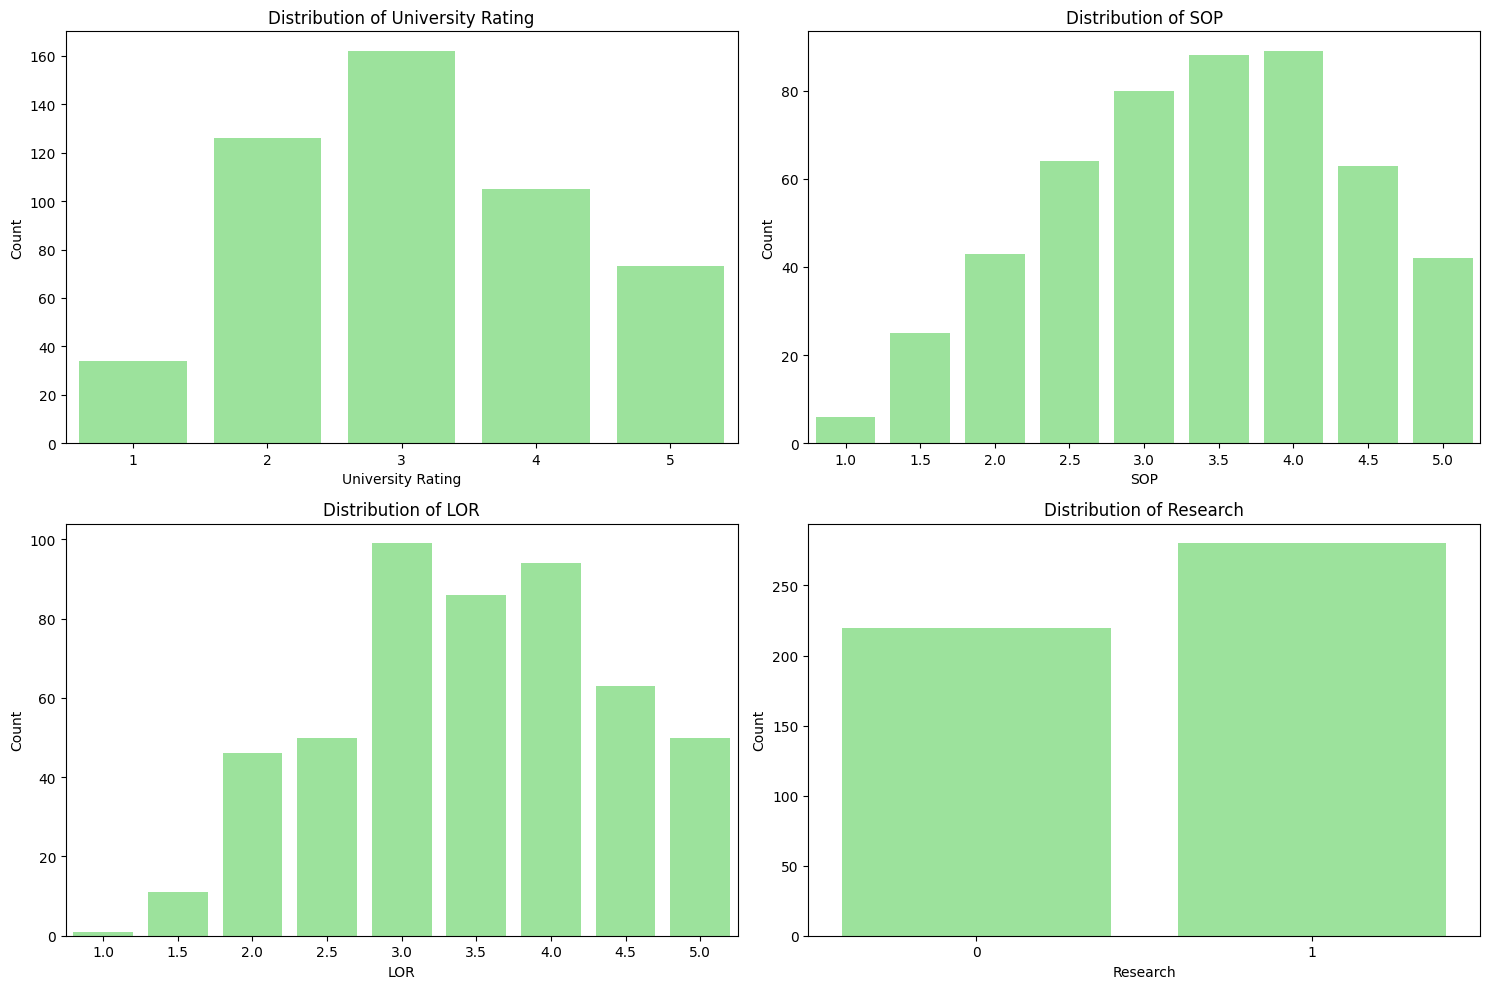

In [12]:
# Countplot for Categorial Columns

plt.figure(figsize=(15,10))
for i, col in enumerate(cat_cols):
  plt.subplot(2,2,i+1)
  sns.countplot(data=df,  x=col, color='lightgreen')
  plt.title(f'Distribution of {col}')
  plt.xlabel(col)
  plt.ylabel('Count')
  plt.tight_layout()
plt.show()

Observation from the Countplots:
* University Rating : Range of the rating is between 1 and 5, with most
universtities fall into rating of 2,3,4.
* SOP : Distribution range are between 1.0 and 5.0, with highter score between (2.5 to 4.0).
* LOR : Distribution range are between 1.0 and 5.0, with highter score between (3.0 to 4.0).
* Research : Has binary distribution with student who have research experience represented by "1" and who don't "0", there is slight majority in student withe research experience.


**Bivariate Analysis for Categorical Columns vs. Chance of Admit**



C:\Users\SUSHIL PILLAY\AppData\Local\Temp\ipykernel_1376\2986483188.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='Chance of Admit', palette='viridis')
C:\Users\SUSHIL PILLAY\AppData\Local\Temp\ipykernel_1376\2986483188.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='Chance of Admit', palette='viridis')
C:\Users\SUSHIL PILLAY\AppData\Local\Temp\ipykernel_1376\2986483188.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='Chance of Admit', palette='viridis')
C:\Users\SUSHIL PIL

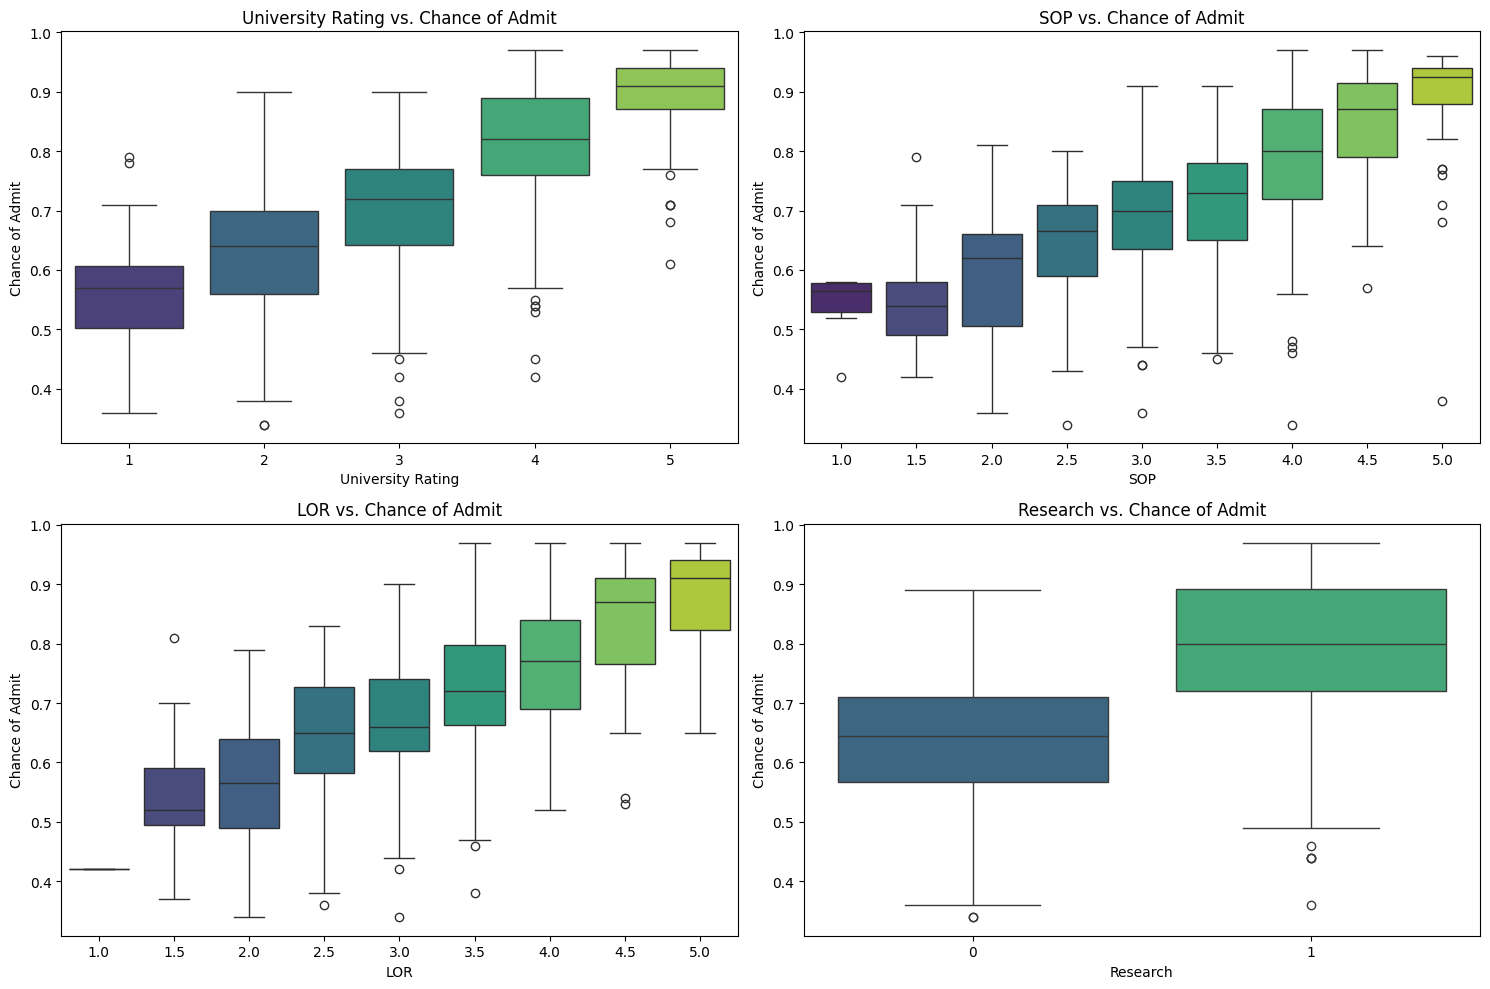

In [13]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_cols):
  plt.subplot(2, 2, i + 1)
  sns.boxplot(data=df, x=col, y='Chance of Admit', palette='viridis')
  plt.title(f'{col} vs. Chance of Admit')
  plt.xlabel(col)
  plt.ylabel('Chance of Admit')
  plt.tight_layout()
plt.show()

Obervation of boxplot:

All the distribution plots show an upward trend, indicating that universities with higher ratings tend to attract applicants who have a higher chances of being admitted.

**Correlation Matrix for Numerical Columns**




,GRE Score,TOEFL Score,CGPA,Chance of Admit
GRE Score,1.000000,0.827200,0.825878,0.810351
TOEFL Score,0.827200,1.000000,0.810574,0.792228
CGPA,0.825878,0.810574,1.000000,0.882413
Chance of Admit,0.810351,0.792228,0.882413,1.000000


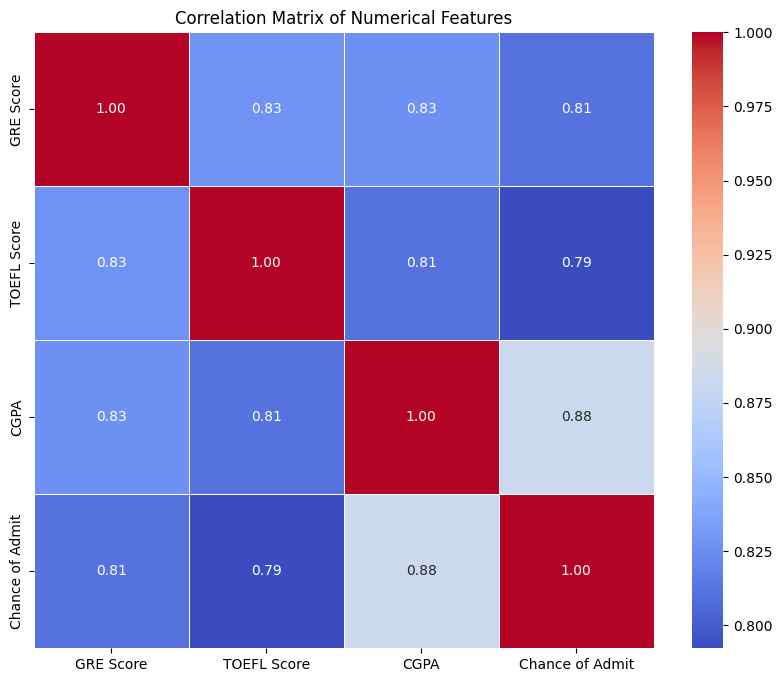

In [14]:
correlation_matrix = df[num_cols].corr()
display(correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

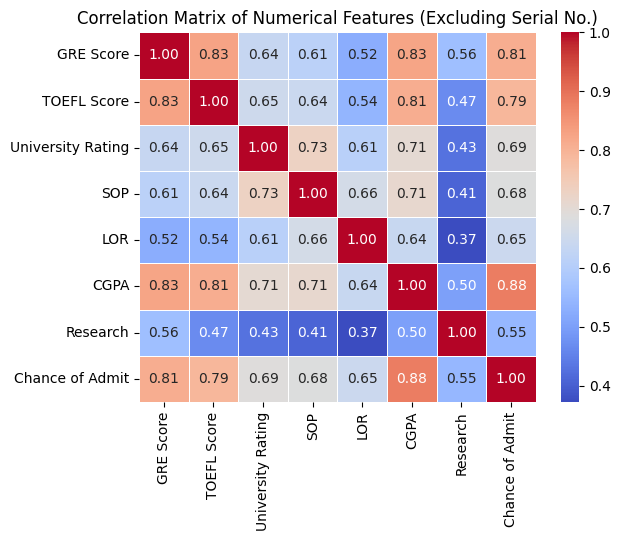

In [15]:
df_corr = df.drop('Serial No.', axis=1).corr(numeric_only=True)
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features (Excluding Serial No.)')
plt.show()

**Insights based on EDA -**

**Distribution of Numerical Columns (Histogram) -**
* GRE_Score is having a range between 290 and 340 with higher score around ( 312 - 324 ).
* TOEFL_Score is having a range between maybe 90 and 120 with higher score around ( 105 - 115 ).
* CGPA_Score is having a range between 6 and 10 with higher score around ( 8.0 - 9.0 ).
* Chance of Admit score is having a range between 0 and 1.0 with higher score around ( 0.70-0.75 ).


**Anlysis for Categorical columns (Countplot) -**
* University Rating : Range of the rating is between 1 and 5, with most universtities fall into rating of 2,3,4.
* SOP : Distribution range are between 1.0 and 5.0, with highter score between (2.5 to 4.0).
* LOR : Distribution range are between 1.0 and 5.0, with highter score between (3.0 to 4.0).
* Research : Has binary distribution with student who have research experience represented by "1" and who don't "0", there is slight majority in student withe research experience.


**Analysis for Categorical Columns vs. Chance of Admit ( BoxPlot ):**

* All the distribution plots show an upward trend, indicating that universities with higher ratings tend to attract applicants who have a higher chances of being admitted.

**Correlation Matrix for Numerical Columns:**
* CGPA and Chance of Admit: There are stong postive correlation between CGPA and Chance of Admit(0.88), which we can say that student with higher CGPA has higher chance of admission.
* GRE_score (0.81) and TOEFL Score(0.79) have strong postive correlation with Chance of admit : High scores and strong chances of admission.
* Strong inter-correlation between CGPA (0.88),GRE_score (0.81) and TOEFL Score(0.79).



**Data Prepocessing**



----

**Missing value check -**

In [16]:
df.isnull().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

No missing value present in the dataset.

**Duplicate check -**

In [17]:
duplicates_all = df.duplicated().sum()
print(duplicates_all)

0


In [18]:
df = df.drop('Serial No.', axis=1)
print(df.head())

   GRE Score  TOEFL Score  University Rating  SOP  LOR  CGPA  Research  \
0        337          118                  4  4.5  4.5  9.65         1   
1        324          107                  4  4.0  4.5  8.87         1   
2        316          104                  3  3.0  3.5  8.00         1   
3        322          110                  3  3.5  2.5  8.67         1   
4        314          103                  2  2.0  3.0  8.21         0   

   Chance of Admit  
0             0.92  
1             0.76  
2             0.72  
3             0.80  
4             0.65  


In [19]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


**Outlier Checks and Treatment -**

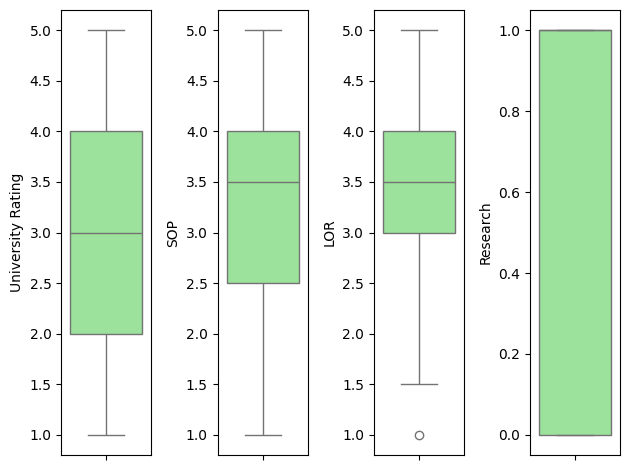

In [20]:
col = 1
for i in cat_cols:
  plt.subplot(1,4,col)
  sns.boxplot(y=df[i], color='lightgreen')
  col += 1
  plt.tight_layout()
plt.show()


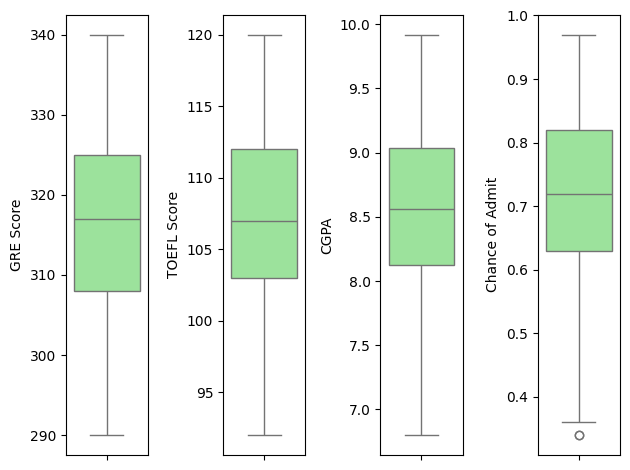

In [21]:
col = 1
for i in num_cols:
  plt.subplot(1,4,col)
  sns.boxplot(y=df[i], color='lightgreen')
  col += 1
  plt.tight_layout()
plt.show()


Assigning Predicator and Target Variables

In [22]:
x = df.drop('Chance of Admit', axis=1)
y = df['Chance of Admit']

In [23]:
x.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0


In [24]:
y.head()

0    0.92
1    0.76
2    0.72
3    0.80
4    0.65
Name: Chance of Admit, dtype: float64

**Model Building**

-----

**Building the Linear Regression model.**

We would split the the data in 80-20 ration, where 80% is the training and 20% would be test data.
Where y is our target varible that is "Chance of admit".

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np

**Splitting the data**

In [26]:
X_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

**Linear Regression model**

In [27]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(x_test)

# MAE
mae = np.mean(np.abs(y_test - y_pred))
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# RMSE
mse = np.mean((y_test - y_pred)**2)
rmse = np.sqrt(mse)
print(f"Mean Squared Error (RMSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# R-squared
ss_res = np.sum((y_test - y_pred)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2 = 1 -(ss_res / ss_tot)
print(f"R-squared (R2): {r2:.4f}")

# Adjusted R2
Adj_R2 = 1 - (1-r2)*(len(y_test)-1) / (len(y_test)-x_test.shape[1]-1)
print(f"Adjusted R-squared (R2): {Adj_R2:.4f}")


Mean Absolute Error (MAE): 0.0427
Mean Squared Error (RMSE): 0.0037
Root Mean Squared Error (RMSE): 0.0609
R-squared (R2): 0.8188
Adjusted R-squared (R2): 0.8051


In [28]:
# checking MEtrics for both Train and Test data
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np # Ensure numpy is imported for np.sqrt
import pandas as pd # Ensure pandas is imported for DataFrame

# Predictions for Linear Regression (Training Data)
y_pred_train_lin_reg = model.predict(X_train)

# Metrics for Linear Regression (Training Data)
mae_train_lin_reg = mean_absolute_error(y_train, y_pred_train_lin_reg)
mse_train_lin_reg = mean_squared_error(y_train, y_pred_train_lin_reg)
rmse_train_lin_reg = np.sqrt(mse_train_lin_reg)
r2_train_lin_reg = r2_score(y_train, y_pred_train_lin_reg)

# Adjusted R2 for Training Data
n_train = len(y_train)
p_train = X_train.shape[1]
adj_r2_train_lin_reg = 1 - (1 - r2_train_lin_reg) * (n_train - 1) / (n_train - p_train - 1)

print("Linear Regression Model Statistics (Training Data):")
print(f"  Mean Absolute Error (MAE): {mae_train_lin_reg:.4f}")
print(f"  Mean Squared Error (MSE): {mse_train_lin_reg:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_train_lin_reg:.4f}")
print(f"  R-squared (R2): {r2_train_lin_reg:.4f}")
print(f"  Adjusted R-squared (Adj R2): {adj_r2_train_lin_reg:.4f}")


# y_pred is already calculated for test data in cell K_FC23rrcU85: y_pred = model.predict(x_test)
# Metrics for Linear Regression (Test Data)
mae_test_lin_reg = mean_absolute_error(y_test, y_pred) # y_pred here refers to test predictions from the LinearRegression model
mse_test_lin_reg = mean_squared_error(y_test, y_pred)
rmse_test_lin_reg = np.sqrt(mse_test_lin_reg)
r2_test_lin_reg = r2_score(y_test, y_pred)

# Adjusted R2 for Test Data
n_test = len(y_test)
p_test = x_test.shape[1]
adj_r2_test_lin_reg = 1 - (1 - r2_test_lin_reg) * (n_test - 1) / (n_test - p_test - 1)

print("\nLinear Regression Model Statistics (Test Data):")
print(f"  Mean Absolute Error (MAE): {mae_test_lin_reg:.4f}")
print(f"  Mean Squared Error (MSE): {mse_test_lin_reg:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_test_lin_reg:.4f}")
print(f"  R-squared (R2): {r2_test_lin_reg:.4f}")
print(f"  Adjusted R-squared (Adj R2): {adj_r2_test_lin_reg:.4f}")

Linear Regression Model Statistics (Training Data):
  Mean Absolute Error (MAE): 0.0425
  Mean Squared Error (MSE): 0.0035
  Root Mean Squared Error (RMSE): 0.0594
  R-squared (R2): 0.8211
  Adjusted R-squared (Adj R2): 0.8179

Linear Regression Model Statistics (Test Data):
  Mean Absolute Error (MAE): 0.0427
  Mean Squared Error (MSE): 0.0037
  Root Mean Squared Error (RMSE): 0.0609
  R-squared (R2): 0.8188
  Adjusted R-squared (Adj R2): 0.8051


### Linear Regression Model Coefficients
These coefficients indicate the strength and direction of the relationship between each predictor variable and the target variable ('Chance of Admit').

In [29]:
coeff_df = pd.DataFrame({'Feature': x.columns, 'Coefficient': model.coef_})
display(coeff_df.sort_values(by='Coefficient', ascending=False))

,Feature,Coefficient
5,CGPA,0.112527
6,Research,0.024027
4,LOR,0.017238
1,TOEFL Score,0.002996
2,University Rating,0.002569
0,GRE Score,0.002434
3,SOP,0.001814


### Ridge and Lasso Regression
Ridge and Lasso are regularization techniques that can help prevent overfitting, especially when dealing with multicollinearity or a large number of features. Let's see how they perform on our data.

In [30]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd # Ensure pandas is imported for DataFrame

# Ridge Regression
ridge_model = Ridge(alpha=1.0) # You can tune alpha
ridge_model.fit(X_train, y_train)

# Predictions for Ridge
y_pred_ridge_train = ridge_model.predict(X_train)
y_pred_ridge_test = ridge_model.predict(x_test)

# Metrics for Ridge Regression (Training Data)
mae_ridge_train = mean_absolute_error(y_train, y_pred_ridge_train)
mse_ridge_train = mean_squared_error(y_train, y_pred_ridge_train)
rmse_ridge_train = np.sqrt(mse_ridge_train)
r2_ridge_train = r2_score(y_train, y_pred_ridge_train)

# Adjusted R2 for Ridge (Training Data)
n_train = len(y_train)
p_train = X_train.shape[1]
adj_r2_ridge_train = 1 - (1 - r2_ridge_train) * (n_train - 1) / (n_train - p_train - 1)

print("Ridge Regression Model Statistics (Training Data):")
print(f"  Mean Absolute Error (MAE): {mae_ridge_train:.4f}")
print(f"  Mean Squared Error (MSE): {mse_ridge_train:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_ridge_train:.4f}")
print(f"  R-squared (R2): {r2_ridge_train:.4f}")
print(f"  Adjusted R-squared (Adj R2): {adj_r2_ridge_train:.4f}")

# Metrics for Ridge Regression (Test Data)
mae_ridge_test = mean_absolute_error(y_test, y_pred_ridge_test)
mse_ridge_test = mean_squared_error(y_test, y_pred_ridge_test)
rmse_ridge_test = np.sqrt(mse_ridge_test)
r2_ridge_test = r2_score(y_test, y_pred_ridge_test)

# Adjusted R2 for Ridge (Test Data)
n_test = len(y_test)
p_test = x_test.shape[1]
adj_r2_ridge_test = 1 - (1 - r2_ridge_test) * (n_test - 1) / (n_test - p_test - 1)

print("\nRidge Regression Model Statistics (Test Data):")
print(f"  Mean Absolute Error (MAE): {mae_ridge_test:.4f}")
print(f"  Mean Squared Error (MSE): {mse_ridge_test:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_ridge_test:.4f}")
print(f"  R-squared (R2): {r2_ridge_test:.4f}")
print(f"  Adjusted R-squared (Adj R2): {adj_r2_ridge_test:.4f}")

coeff_df_ridge = pd.DataFrame({'Feature': x.columns, 'Coefficient': ridge_model.coef_})
print("\nRidge Regression Coefficients:")
display(coeff_df_ridge.sort_values(by='Coefficient', ascending=False))



Ridge Regression Model Statistics (Training Data):
  Mean Absolute Error (MAE): 0.0425
  Mean Squared Error (MSE): 0.0035
  Root Mean Squared Error (RMSE): 0.0594
  R-squared (R2): 0.8210
  Adjusted R-squared (Adj R2): 0.8178

Ridge Regression Model Statistics (Test Data):
  Mean Absolute Error (MAE): 0.0429
  Mean Squared Error (MSE): 0.0037
  Root Mean Squared Error (RMSE): 0.0610
  R-squared (R2): 0.8180
  Adjusted R-squared (Adj R2): 0.8041

Ridge Regression Coefficients:


,Feature,Coefficient
5,CGPA,0.109079
6,Research,0.023679
4,LOR,0.017478
1,TOEFL Score,0.003073
2,University Rating,0.002767
0,GRE Score,0.002521
3,SOP,0.002164


In [31]:
# Lasso Regression
lasso_model = Lasso(alpha=0.01) # You can tune alpha
lasso_model.fit(X_train, y_train)

# Predictions for Lasso
y_pred_lasso_train = lasso_model.predict(X_train)
y_pred_lasso_test = lasso_model.predict(x_test)

# Metrics for Lasso Regression (Training Data)
mae_lasso_train = mean_absolute_error(y_train, y_pred_lasso_train)
mse_lasso_train = mean_squared_error(y_train, y_pred_lasso_train)
rmse_lasso_train = np.sqrt(mse_lasso_train)
r2_lasso_train = r2_score(y_train, y_pred_lasso_train)

# Adjusted R2 for Lasso (Training Data)
n_train = len(y_train)
p_train = X_train.shape[1]
adj_r2_lasso_train = 1 - (1 - r2_lasso_train) * (n_train - 1) / (n_train - p_train - 1)

print("\nLasso Regression Model Statistics (Training Data):")
print(f"  Mean Absolute Error (MAE): {mae_lasso_train:.4f}")
print(f"  Mean Squared Error (MSE): {mse_lasso_train:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_lasso_train:.4f}")
print(f"  R-squared (R2): {r2_lasso_train:.4f}")
print(f"  Adjusted R-squared (Adj R2): {adj_r2_lasso_train:.4f}")

# Metrics for Lasso Regression (Test Data)
mae_lasso_test = mean_absolute_error(y_test, y_pred_lasso_test)
mse_lasso_test = mean_squared_error(y_test, y_pred_lasso_test)
rmse_lasso_test = np.sqrt(mse_lasso_test)
r2_lasso_test = r2_score(y_test, y_pred_lasso_test)

# Adjusted R2 for Lasso (Test Data)
n_test = len(y_test)
p_test = x_test.shape[1]
adj_r2_lasso_test = 1 - (1 - r2_lasso_test) * (n_test - 1) / (n_test - p_test - 1)

print("\nLasso Regression Model Statistics (Test Data):")
print(f"  Mean Absolute Error (MAE): {mae_lasso_test:.4f}")
print(f"  Mean Squared Error (MSE): {mse_lasso_test:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_lasso_test:.4f}")
print(f"  R-squared (R2): {r2_lasso_test:.4f}")
print(f"  Adjusted R-squared (Adj R2): {adj_r2_lasso_test:.4f}")

coeff_df_lasso = pd.DataFrame({'Feature': x.columns, 'Coefficient': lasso_model.coef_})
print("\nLasso Regression Coefficients:")
display(coeff_df_lasso.sort_values(by='Coefficient', ascending=False))


Lasso Regression Model Statistics (Training Data):
  Mean Absolute Error (MAE): 0.0502
  Mean Squared Error (MSE): 0.0045
  Root Mean Squared Error (RMSE): 0.0671
  R-squared (R2): 0.7713
  Adjusted R-squared (Adj R2): 0.7673

Lasso Regression Model Statistics (Test Data):
  Mean Absolute Error (MAE): 0.0540
  Mean Squared Error (MSE): 0.0056
  Root Mean Squared Error (RMSE): 0.0747
  R-squared (R2): 0.7271
  Adjusted R-squared (Adj R2): 0.7064

Lasso Regression Coefficients:


,Feature,Coefficient
5,CGPA,0.020019
4,LOR,0.017018
1,TOEFL Score,0.005953
0,GRE Score,0.005835
2,University Rating,0.002685
3,SOP,0.001500
6,Research,0.000000


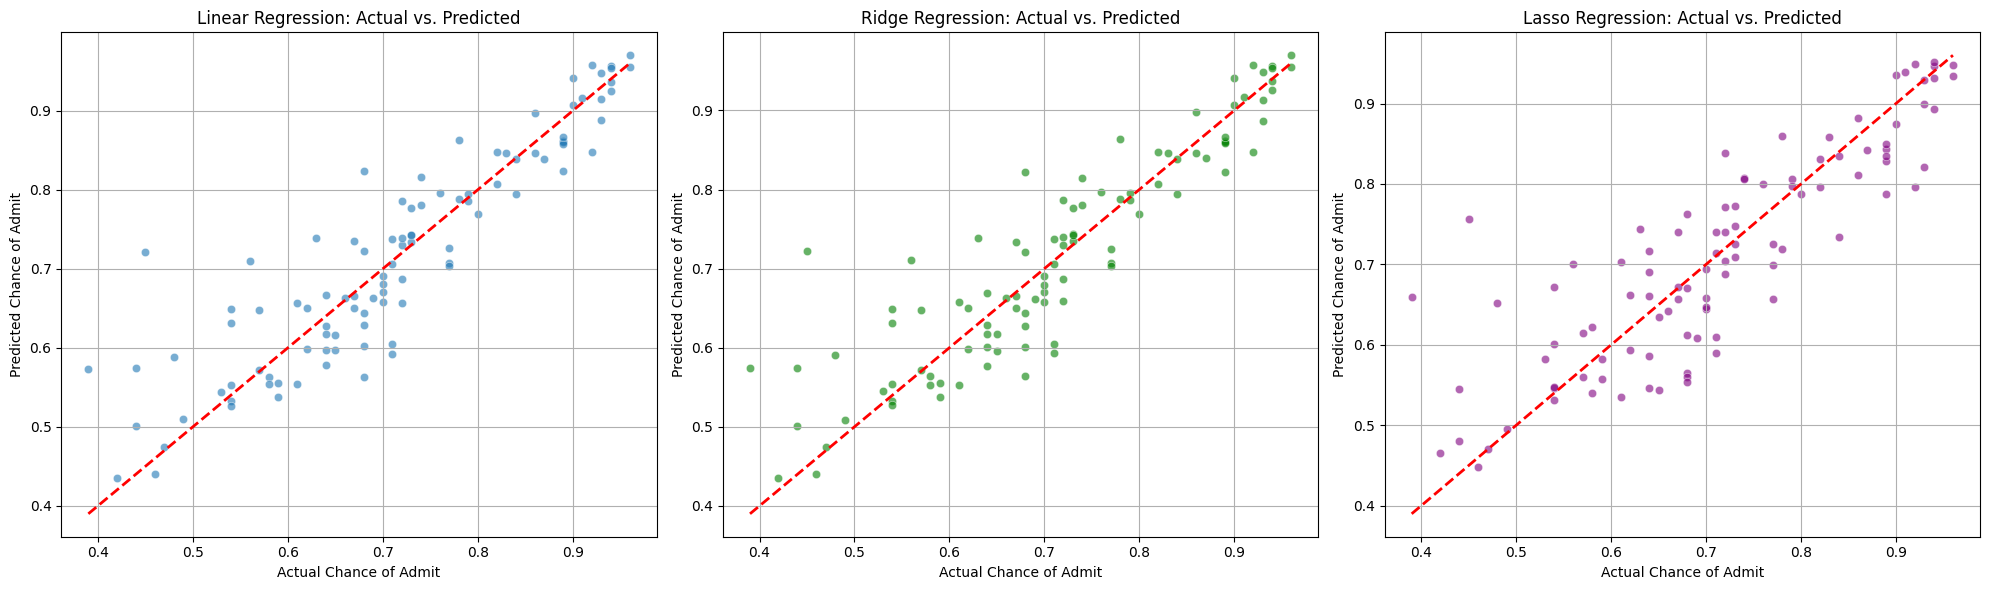

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 6)) # Adjust figure size for three subplots

# Subplot 1: Linear Regression
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Linear Regression: Actual vs. Predicted')
plt.xlabel('Actual Chance of Admit')
plt.ylabel('Predicted Chance of Admit')
plt.grid(True)

# Subplot 2: Ridge Regression
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
sns.scatterplot(x=y_test, y=y_pred_ridge_test, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Ridge Regression: Actual vs. Predicted')
plt.xlabel('Actual Chance of Admit')
plt.ylabel('Predicted Chance of Admit')
plt.grid(True)

# Subplot 3: Lasso Regression
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
sns.scatterplot(x=y_test, y=y_pred_lasso_test, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Lasso Regression: Actual vs. Predicted')
plt.xlabel('Actual Chance of Admit')
plt.ylabel('Predicted Chance of Admit')
plt.grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

### Visualization Insights

Insights from Actual vs. Predicted Plots
These scatter plots illustrate how closely each model's predictions align with the actual 'Chance of Admit' values on the test set:

Linear Regression and Ridge Regression: Both plots show that the predicted values cluster closely around the classifier. This indicates that these models are making accurate predictions, with a strong linear relationship between actual and predicted values. The spread of points is relatively tight, suggesting good predictive power.

Lasso Regression: The Lasso plot shows a slightly wider scatter of points around the red diagonal line compared to Linear and Ridge Regression. This visually confirms the earlier observation from the Adjusted R-squared comparison that Lasso Regression, while performing feature selection, has a slightly lower predictive accuracy on this dataset with the chosen alpha.

**Testing the assumptions of the linear regression model**

----

Multicollinearity check by VIF score (variables are dropped one-by-one till none has VIF>5)

Ordinary Least Squares (OLS) regression is a statistical method used to estimate the relationship between one or more independent variables (predictors) and a dependent variable (outcome).

In [33]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

scalar = StandardScaler()
X_scaled = scalar.fit_transform(X_train)

X_sm = sm.add_constant(X_scaled) # Statmodels id without intercept, to add intercept we need to add constant.

sm_model = sm.OLS(y_train, X_sm).fit()
print(sm_model.summary())

# Map x1, x2, etc., to actual feature names for easier interpretation.
feature_names = ['const'] + list(X_train.columns)
print("\nMapping of coefficients to original features:")
for i, name in enumerate(feature_names):
    print(f"x{i} (or const for intercept): {name}")

                            OLS Regression Results                            
Dep. Variable:        Chance of Admit   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     257.0
Date:                Mon, 18 May 2026   Prob (F-statistic):          3.41e-142
Time:                        01:51:16   Log-Likelihood:                 561.91
No. Observations:                 400   AIC:                            -1108.
Df Residuals:                     392   BIC:                            -1076.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7242      0.003    241.441      0.0

**Interpretation of OLS Regression Results:**


1.Model Fit:
* R-Squared(0.821) : This indicated that it is a good fit as 82.1% of the variance in the "Chance of Admit" can be explained by the predictor variable in the model.
* Adjusted R-Squared(0.818) : It indicates the number of predictors in the model, 81.8% menans model fits data well.

2.Coefficient and P_values:
* CGPA (x6): coef = 0.0676, P>|t| = 0.000: It is a strong predicator, as the coefficeint is (0.0676) with high significant value.
* GRE Score (x1): coef = 0.0267, P>|t| = 0.000: GRE Score is also statistically significant and has a positive impact on 'Chance of Admit'.
* TOEFL Score (x2): coef = 0.0182, P>|t| = 0.002: TOEFL Score is statistically significant and has a positive impact, though slightly less than GRE Score.
* LOR (x5): coef = 0.0159, P>|t| = 0.000: LOR (Letter of Recommendation strength) is statistically significant and positively impacts 'Chance of Admit'.
* Research (x7): coef = 0.0119, P>|t| = 0.001: Having research experience is statistically significant and positively impacts 'Chance of Admit'.
* University Rating (x3): coef = 0.0029, P>|t| = 0.541 : This result suggest that the University rating does not have statistical significant linear relationship (p_value>0.05) in predicting the Chance of Admit in the model.
* SOP (x4): coef = 0.0018, P>|t| = 0.721: Similarly with University Rating, SOP does not have significant relationship (p_value>0.05)  with Chance of Admit.

In summary, the OLS regression model suggests that CGPA, GRE Score, TOEFL Score, LOR, and Research are the most significant positive predictors of 'Chance of Admit'. University Rating and SOP, while intuitively important, do not show a statistically significant independent effect in this linear model after accounting for the other factors.

In [34]:
# VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['Features'] = X_train.columns
vif['VIF'] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by="VIF", ascending=False)
display(vif)

,Features,VIF
5,CGPA,4.65
0,GRE Score,4.49
1,TOEFL Score,3.66
3,SOP,2.79
2,University Rating,2.57
4,LOR,1.98
6,Research,1.52


VIF between 1 and 5: Generally considered acceptable.

All VIF values are below 5 → This means no serious multicollinearity problem.

Since your highest VIF is 4.65 (CGPA), all predictors are within the safe zone.

**Calculate the Residuals -**

In [35]:
residuals = y_test - y_pred
print(f"Mean of test residuals: {residuals.mean():.4f}")


Mean of test residuals: -0.0055


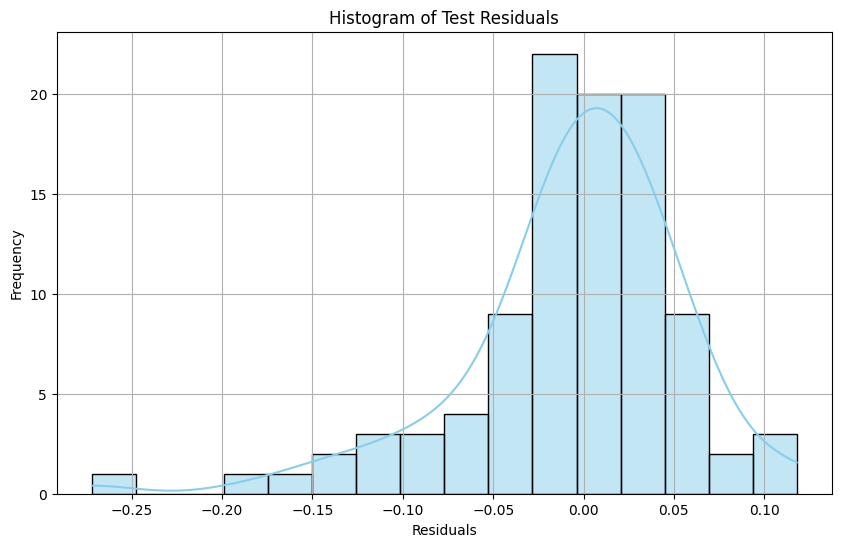

In [36]:
plt.figure(figsize=(10,6))
sns.histplot(residuals, kde= True, color ='skyblue')
plt.title('Histogram of Test Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

The histogram is left-skewed in negative side, but it shows a distribution that appears somewhat normal, centered around zero, which is a good sign for the linear regression model.

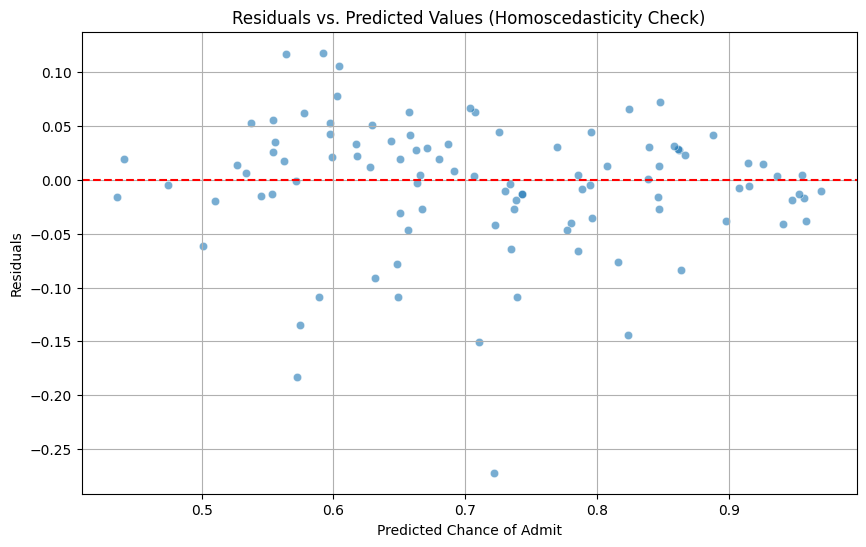

In [37]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values (Homoscedasticity Check)')
plt.xlabel('Predicted Chance of Admit')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()


From the 'Residuals vs. Predicted Values' scatter plot, we can observe that the spread of the residuals is not constant across all predicted values.

In [38]:
Y_hat = sm_model.predict(X_sm)
errors = Y_hat - y_train
print(errors)

249    0.023197
433    0.035079
19     0.024015
322   -0.047252
332   -0.099054
         ...   
106   -0.004942
270   -0.071557
348   -0.103162
435    0.038193
102    0.041603
Name: Chance of Admit, Length: 400, dtype: float64


Text(0.5, 1.0, 'Histogram of residuals')

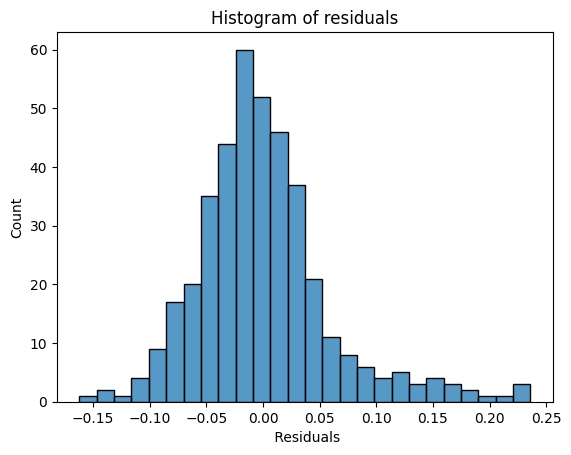

In [39]:
import seaborn as sns
sns.histplot(errors)
plt.xlabel(" Residuals")
plt.title("Histogram of residuals")

Text(0.5, 1.0, 'Predicted values vs Residuals')

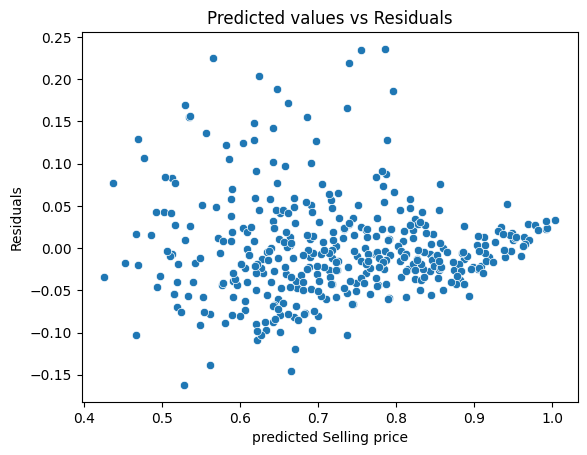

In [40]:
sns.scatterplot(x=Y_hat,y=errors)
plt.xlabel("predicted Selling price")
plt.ylabel("Residuals")
plt.title("Predicted values vs Residuals")

In [41]:
# Performin the Breusch Pagan test 
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# X_const is your predictors with constant added
bp_test = het_breuschpagan(sm_model.resid, X_sm)
print("Breusch-Pagan Test:", bp_test)

Breusch-Pagan Test: (np.float64(25.15586569245505), np.float64(0.0007119983594308687), np.float64(3.7581713300111965), np.float64(0.0005879783560629781))


In [42]:
# Performing the Goldfeld-Quandt test to check for Homoscedasticity -
from statsmodels.compat import lzip
import statsmodels.stats.api as sms

name = ['F statistic', 'p-value']
test = sms.het_goldfeldquandt(y_train, X_sm)
lzip(name, test)

[('F statistic', np.float64(0.9506884043302333)),
 ('p-value', np.float64(0.6367845922443407))]

 The Goldfeld–Quandt test compares variance of residuals across subsets of data to detect heteroscedasticity. A small p‑value means your residuals’ variance is not constant.
Since the p‑value = 0.637 > 0.05, you fail to reject H₀.
This means there is no evidence of heteroscedasticity in your model — the residuals appear to have constant variance.

<Figure size 800x600 with 0 Axes>

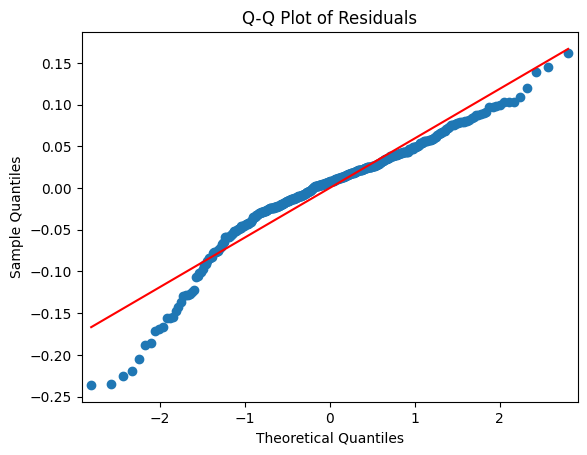

In [43]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sm.qqplot(sm_model.resid, line='s') # 's' for standardized line
plt.title('Q-Q Plot of Residuals')
plt.show()

For QQ plot, we observe that the points are largely fall along the 'S' Standarized line, and they are mostly centred, which we can say that it is normally distributed. We can also see the in the tail areas some departures from the perfect normality, but the overall, the assumption seems reasonably met for the core of data.

**Actionable Insights & Recommendations**


1.Significance of Predictor Variables:
* The OLS regression model shows **CGPA, GRE Score, TOEFL Score, and LOR** as highly significant positive predictors of a student's **'Chance of Admit'**. This means that stronget academic performance (CGPA), higher standardized test Scores(GRE, TOEFL), and better letters of recommendation are crucial factors.
* **Research** Experience also shows a statistically significant postive impact, indicating its value in the admission process.
* **University Rating and SOP**, while intuitively important, do not show a statistically significant independent effect in this linear model after accounting for the other factors.


2. **Model Performances:**

* **Linear Regression** model acheived a respectable Adjusted R-squared (R2) of around **0.80-0.82** on both training and test data, indicating that it explain good linear relationship with Chance of Admit.
* **Ridge Regression** performed very similar to linear regression.
* **Lasso Regression:** The Lasso plot shows a slightly wider scatter of points around the red diagonal line compared to Linear and Ridge Regression. This visually confirms the earlier observation from the Adjusted R-squared comparison that Lasso Regression, while performing feature selection, has a slightly lower predictive accuracy on this dataset with the chosen alpha.


3. **Addressing Model Assumptions:**

* **Normality of Residuals:** The Q-Q plot suggests that residuals are approximately normally distributed, which is a good indication.
* **Homoscedasticity:**  The conflicting results from the Breusch-Pagan (heteroscedasticity) and Goldfeld-Quandt (homoscedasticity) tests allowed us to proceed with valid statistical inference without needing to drastically alter the model or transform the target variable, which could complicate interpretation.
* **Multicollinearity:** The VIF scores were all below 5, confirming that multicollinearity is not a significant problem among the independent variables.



**Recommendations for Model Improvement and Implementation:**

1. **Explore Non-Linear Relationships:** While linear models performed well, we could consider exploring non-linear relationships between features.
2. **Feature Engineering:** Create new features that might capture more complex relationships.For examples - Combined Scores of GRE, TOEFL and CGPA.
3. **Additional Data Sources for Model Improvement:**
  * **University Placement data** : Information on what kind of company comes for placements in the university.
  * **Applicant Demographics** : Information of applicants such as interships, researches poublished, extracurricular activities, undergraduate institution reputaton could add signitificant predicative powers also increase the Chance of Admit.
4. **Model Implementation in Real World ( For Jamboree ):**
  * **Interactive tool**: Implementing this model as an interactive tool on Jamboree's Website. Students can imput their scores and instanly get a 'Chance of Admit' predication, along with personlized feedback on aread to improve.
  * **Personlized Study plans**: Using the models it will provide insights to generate tailored study recommendation. IF GRE score has a high coefficent, suggest focused GRE preparation.
  * **Counselor Aid**: Jamboree counselors can used this model to guide students more effectively.

**Potential Business Benefits from Improving the Model:**

* **Increased Student Engagement**: A more accurate and insightful prediction tool will attract more student to Jamboree's Platform.
* **Enhanced Credibility**: Providing data-backed prediction will boost Jamboree's reputation as reliable and effective admission consultancy.
* **Improved Admission Rates**: More precise guidance can lead to higher admission rates for Jamboree's students, translate to more sucess stories and increased business.
* **Optimized Resource Allocation**: Understanding most impactful factors allows Jamboree to focus its counseling and test prep resources on areas that gives the highest returens for students.
* **Competitive Advantage** : This model help Jamboree reinforces its position as a leader in education consulting.

